In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import calendar

In [2]:
coffee_sales = pd.read_csv('datasets/rolling-up-looking-back/coffee_shop_sales.csv', parse_dates=['date'])
# Create month column and make it categorical so that it's chronologically ordered
coffee_sales['month'] = pd.Categorical(
    coffee_sales['date'].dt.month_name(),
    categories=list(calendar.month_name)[1:],
    ordered=True
)
coffee_sales

,order_id,date,store,product,quantity,sales,month
0,1,2023-01-01,Lower Manhattan,Gourmet brewed coffee,2,6.00,January
1,2,2023-01-01,Lower Manhattan,Brewed Chai tea,2,6.20,January
2,3,2023-01-01,Lower Manhattan,Hot chocolate,2,9.00,January
3,4,2023-01-01,Lower Manhattan,Drip coffee,1,2.00,January
4,5,2023-01-01,Lower Manhattan,Brewed Chai tea,2,6.20,January
...,...,...,...,...,...,...,...
149111,149452,2023-06-30,Hell's Kitchen,Brewed herbal tea,2,5.00,June
149112,149453,2023-06-30,Hell's Kitchen,Brewed Black tea,2,6.00,June
149113,149454,2023-06-30,Hell's Kitchen,Brewed herbal tea,1,3.00,June
149114,149455,2023-06-30,Hell's Kitchen,Barista Espresso,1,3.75,June


In [3]:
total_sales = coffee_sales.groupby(['month', 'store'], as_index=False, observed=True)['sales'].sum()
total_sales

,month,store,sales
0,January,Astoria,27313.66
1,January,Hell's Kitchen,27820.65
2,January,Lower Manhattan,26543.43
3,February,Astoria,25105.34
4,February,Hell's Kitchen,25719.80
5,February,Lower Manhattan,25320.05
6,March,Astoria,32835.43
7,March,Hell's Kitchen,33110.57
8,March,Lower Manhattan,32888.68
9,April,Astoria,39477.61


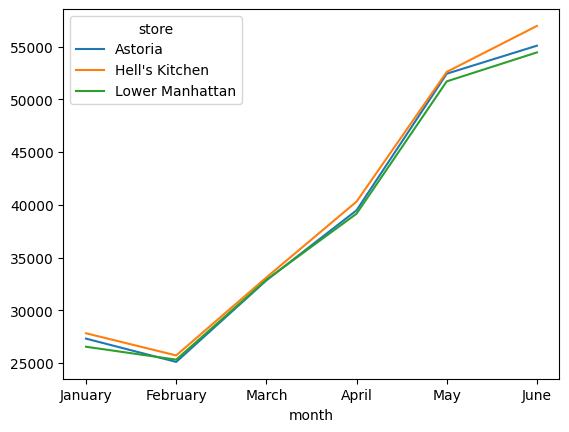

In [4]:
pivot = total_sales.pivot(columns='store', index='month', values='sales')
pivot.plot(kind='line')
plt.show()

In [5]:
total_sales['sales_diff'] = total_sales.groupby('store')['sales'].diff()
total_sales

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,month,store,sales,sales_diff
0,January,Astoria,27313.66,NaN
1,January,Hell's Kitchen,27820.65,NaN
2,January,Lower Manhattan,26543.43,NaN
3,February,Astoria,25105.34,-2208.32
4,February,Hell's Kitchen,25719.80,-2100.85
5,February,Lower Manhattan,25320.05,-1223.38
6,March,Astoria,32835.43,7730.09
7,March,Hell's Kitchen,33110.57,7390.77
8,March,Lower Manhattan,32888.68,7568.63
9,April,Astoria,39477.61,6642.18


## What was the difference in sales from April to May for the Astoria location? (digits only, rounded to the nearest dollar)

In [6]:
total_sales.query('month == "May" and store == "Astoria"')['sales_diff'].round()

12    12951.0
Name: sales_diff, dtype: float64